# EPA Hyperparameter Tuning via Log-Probability Maximization

Tunes **layer selection** and **steering coefficient** for each EPA dimension using a
regression-style log-probability metric inspired by the RepE paper (Section C.2).

**Method:**
1. Generate calibration utterances with known EPA ground-truth labels
2. For each utterance, construct a D.3.2-style Likert evaluation prompt
3. Apply steering vectors, compute expected Likert value from the model's token probabilities
4. Measure Spearman rank correlation with ground-truth targets
5. Grid-search over (layers, coefficient) to maximize on-target correlation while minimizing cross-dimension interference

**Run Cells 1–4 once** to generate and save the dataset, then skip to Cell 5 on subsequent runs.

In [1]:
# === Cell 1: Setup & Imports ===

import sys
sys.path.append('../..')

import os
import json
import pickle
import itertools
from datetime import datetime

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

from repe import repe_pipeline_registry
from repe.rep_control_reading_vec import WrappedReadingVecModel

repe_pipeline_registry()

from examples.act_new.act_core import EPA
from examples.act_new.epa_calibration import BehaviorPromptGenerator
from examples.act_new.utils import (
    format_llama3_prompt,
    make_epa_activations,
)

print("All imports OK.")

c:\Users\Kyra\mambaforge-pypy3\envs\repeng\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK.


In [2]:
# === Cell 2: Load Model & Directions ===

# Load directions
directions_path = "epa_directions.pkl"
with open(directions_path, 'rb') as f:
    directions_data = pickle.load(f)

rep_readers = directions_data['rep_readers']
hidden_layers = directions_data['hidden_layers']
model_name = directions_data['model_name']

print(f"Loaded directions for model: {model_name}")
print(f"Dimensions: {list(rep_readers.keys())}")
print(f"Layers: {len(hidden_layers)} ({hidden_layers[0]}..{hidden_layers[-1]})")

# Load model
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto",
)
tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left")
tokenizer.pad_token = tokenizer.eos_token

print(f"Model loaded: {model_name}")

Loaded directions for model: meta-llama/Llama-3.1-8B-Instruct
Dimensions: ['evaluation', 'potency', 'activity']
Layers: 31 (-1..-31)


Loading checkpoint shards: 100%|██████████| 4/4 [00:07<00:00,  1.96s/it]


Model loaded: meta-llama/Llama-3.1-8B-Instruct


In [ ]:
# === Cell 3: Generate & Save Tuning Dataset (run once, then skip) ===
#
# Generates utterances for calibration and assigns Likert-scale
# ground-truth labels for every EPA dimension based on dictionary values.

DATASET_PATH = "epa_tuning_dataset.json"

# --- Likert bin mapping ---
LIKERT_OPTIONS = [
    "Very low", "Low", "Somewhat low", "Neutral",
    "Somewhat high", "High", "Very high",
]
LIKERT_VALUES = {label: i + 1 for i, label in enumerate(LIKERT_OPTIONS)}

# EPA values typically range -4.3..+4.3.  Map to 7 bins:
#   <= -3.0  -> Very low (1)
#   <= -1.5  -> Low (2)
#   <= -0.5  -> Somewhat low (3)
#   <=  0.5  -> Neutral (4)
#   <=  1.5  -> Somewhat high (5)
#   <=  3.0  -> High (6)
#   >  3.0   -> Very high (7)

def epa_value_to_likert(value: float) -> str:
    """Map a continuous EPA value to a Likert label."""
    if value <= -3.0:
        return "Very low"
    elif value <= -1.5:
        return "Low"
    elif value <= -0.5:
        return "Somewhat low"
    elif value <= 0.5:
        return "Neutral"
    elif value <= 1.5:
        return "Somewhat high"
    elif value <= 3.0:
        return "High"
    else:
        return "Very high"

# --- LLM utterance generation ---
def epa_to_description(epa: EPA) -> str:
    def scale_term(value, neg_terms, pos_terms):
        if value <= -3.0:   return neg_terms[0]
        elif value <= -1.5: return neg_terms[1]
        elif value <= -0.5: return neg_terms[2]
        elif value <= 0.5:  return neg_terms[3]
        elif value <= 1.5:  return pos_terms[0]
        elif value <= 3.0:  return pos_terms[1]
        else:               return pos_terms[2]

    e_desc = scale_term(epa.e,
        ["very bad", "bad", "somewhat bad", "neither good nor bad"],
        ["somewhat good", "good", "very good"])
    p_desc = scale_term(epa.p,
        ["very impotent", "impotent", "somewhat impotent", "neither potent nor impotent"],
        ["somewhat potent", "potent", "very potent"])
    a_desc = scale_term(epa.a,
        ["very passive", "passive", "somewhat passive", "neither active nor passive"],
        ["somewhat active", "active", "very active"])
    return f"{e_desc}, {p_desc}, and {a_desc}"

def generate_with_llm(behavior: str, epa: EPA) -> str:
    epa_description = epa_to_description(epa)
    behavior_display = behavior.replace("_", " ")
    prompt = format_llama3_prompt(
        "You are simulating a human person engaging in a conversation with another human person.",
        f"Generate a single conversational utterance that embodies the behavior "
        f"'{behavior_display}' with an affective tone that is {epa_description}. "
        f"Respond with only the utterance, no explanation or quotation marks."
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(**inputs, max_new_tokens=100,
                              pad_token_id=tokenizer.eos_token_id)
    new_tokens = outputs[0][inputs['input_ids'].shape[1]:]
    response = tokenizer.decode(new_tokens, skip_special_tokens=True)
    return response.strip().strip('"\'')

# --- Generate dataset ---
generator = BehaviorPromptGenerator()
generator.set_llm_generate_function(generate_with_llm)

# We want diversity across EPA space, so use all available behaviors
behaviors = generator.available_behaviors
n_samples = len(behaviors)  # one utterance per behavior

print(f"Generating {n_samples} utterances from {len(behaviors)} behaviors...")

utterances = []
for behavior in tqdm(behaviors, desc="Generating utterances"):
    epa = generator.get_behavior_epa(behavior)
    if epa is None:
        continue
    text = generator.generate_utterance(behavior, variant=0)
    if text is None or text.startswith("["):  # skip placeholder fallbacks
        continue

    utterances.append({
        "text": text,
        "behavior": behavior,
        "target_epa": {"e": float(epa.e), "p": float(epa.p), "a": float(epa.a)},
        "likert_targets": {
            "evaluation": epa_value_to_likert(epa.e),
            "potency": epa_value_to_likert(epa.p),
            "activity": epa_value_to_likert(epa.a),
        },
    })

dataset = {
    "metadata": {
        "model_name": model_name,
        "generated_at": datetime.now().isoformat(),
        "n_utterances": len(utterances),
    },
    "utterances": utterances,
}

with open(DATASET_PATH, 'w') as f:
    json.dump(dataset, f, indent=2)

print(f"\nSaved {len(utterances)} utterances to {DATASET_PATH}")
print("\nSample entries:")
for u in utterances[:3]:
    print(f"  [{u['behavior']}] \"{u['text'][:80]}...\"")
    print(f"    EPA: {u['target_epa']}  Likert: {u['likert_targets']}")

In [3]:
# === Cell 4: Load Saved Dataset ===

DATASET_PATH = "epa_tuning_dataset.json"

with open(DATASET_PATH, 'r') as f:
    dataset = json.load(f)

utterances = dataset['utterances']
print(f"Loaded {len(utterances)} utterances (generated {dataset['metadata']['generated_at']})")

# Re-define constants needed for the rest of the notebook
LIKERT_OPTIONS = [
    "Very low", "Low", "Somewhat low", "Neutral",
    "Somewhat high", "High", "Very high",
]
LIKERT_VALUES = {label: i + 1 for i, label in enumerate(LIKERT_OPTIONS)}

# Show distribution of Likert targets per dimension
for dim in ["evaluation", "potency", "activity"]:
    counts = {}
    for u in utterances:
        label = u['likert_targets'][dim]
        counts[label] = counts.get(label, 0) + 1
    print(f"\n{dim.capitalize()} distribution:")
    for opt in LIKERT_OPTIONS:
        print(f"  {opt:15s}: {counts.get(opt, 0):3d}")

Loaded 85 utterances (generated 2026-02-26T07:37:11.989946)

Evaluation distribution:
  Very low       :   3
  Low            :  12
  Somewhat low   :   9
  Neutral        :   9
  Somewhat high  :  10
  High           :  32
  Very high      :  10

Potency distribution:
  Very low       :   0
  Low            :   2
  Somewhat low   :   0
  Neutral        :  16
  Somewhat high  :  33
  High           :  34
  Very high      :   0

Activity distribution:
  Very low       :   0
  Low            :   3
  Somewhat low   :   9
  Neutral        :  17
  Somewhat high  :  34
  High           :  22
  Very high      :   0


In [4]:
# === Cell 5: Likert Log-Probability Functions ===

DIMENSION_CONCEPTS = {
    "evaluation": ("goodness", "Goodness"),
    "potency":    ("powerfulness", "Powerfulness"),
    "activity":   ("liveliness", "Liveliness"),
}

def make_likert_prompt(utterance_text: str, dimension: str) -> str:
    """
    Construct a D.3.2-style Likert evaluation prompt.
    
    The prompt asks the model to rate how much <concept> is present
    in the given utterance, answering with one of 7 Likert options.
    The assistant response is pre-filled up to the label token.
    """
    concept, label = DIMENSION_CONCEPTS[dimension]
    user_msg = (
        f"What is the amount of {concept} in the following utterance? "
        f"Please answer using EXACTLY one of the following: "
        f"- 'Very low' - 'Low' - 'Somewhat low' - 'Neutral' "
        f"- 'Somewhat high' - 'High' - 'Very high' "
        f"Utterance: {utterance_text}"
    )
    # Pre-fill assistant response up to the label
    return format_llama3_prompt(None, user_msg, f"{label}: ")


def get_likert_token_ids(tokenizer) -> dict:
    """
    Get single-token IDs for each Likert option's first distinguishing word.
    We use the first word of each option for single-token scoring.
    """
    # Map each Likert option to a distinguishing first token.
    # "Very" appears in both Very low and Very high, so we must handle
    # the compound case by looking at full option text.
    #
    # Strategy: tokenize each full option and take the first token.
    # Then for scoring, we compute P(first_token) and normalize.
    token_ids = {}
    for option in LIKERT_OPTIONS:
        ids = tokenizer.encode(option, add_special_tokens=False)
        token_ids[option] = ids[0]  # first token of each option
    return token_ids


def compute_likert_distribution(
    model, tokenizer, prompt: str, dimension: str
) -> dict:
    """
    Compute probability distribution over 7 Likert options for a prompt.
    
    Returns dict with keys: 'probs' (dict option->prob), 'expected_value' (float 1-7).
    """
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model(**inputs)
        # Logits for the next token (after the pre-filled prompt)
        next_token_logits = outputs.logits[0, -1, :]  # (vocab_size,)
    
    # Get token IDs for each Likert option's distinguishing first word
    # We need to handle "Very low" vs "Very high" specially.
    # Approach: score each full option by summing log-probs of its tokens,
    # but for efficiency, just use the first *distinguishing* token.
    #
    # The options map to these first tokens:
    #   Very (low/high) -> need 2nd token to disambiguate
    #   Low, Somewhat (low/high), Neutral, High -> unique first tokens
    #
    # Simple approach: use first token for unique options,
    # and handle "Very" by looking at 2-token sequence probability.
    
    # Tokenize each option to get token IDs
    option_logprobs = {}
    for option in LIKERT_OPTIONS:
        ids = tokenizer.encode(option, add_special_tokens=False)
        # Use the logit for the first token as the primary signal
        first_token_logit = next_token_logits[ids[0]].item()
        option_logprobs[option] = first_token_logit
    
    # For "Very low" and "Very high", both start with "Very".
    # To disambiguate, we need to compute joint probability:
    # P("Very low") = P("Very") * P("low" | prompt + "Very")
    # P("Very high") = P("Very") * P("high" | prompt + "Very")
    #
    # Compute the conditional for the 2nd token:
    very_ids = tokenizer.encode("Very", add_special_tokens=False)
    extended_input_ids = torch.cat([
        inputs['input_ids'][0],
        torch.tensor(very_ids, device=model.device)
    ]).unsqueeze(0)
    
    with torch.no_grad():
        extended_outputs = model(input_ids=extended_input_ids)
        very_next_logits = extended_outputs.logits[0, -1, :]  # logits after "Very"
    
    # Get the 2nd token IDs for "Very low" and "Very high"
    low_2nd_ids = tokenizer.encode(" low", add_special_tokens=False)
    high_2nd_ids = tokenizer.encode(" high", add_special_tokens=False)
    
    very_base_logit = next_token_logits[very_ids[0]].item()
    
    # Joint log-probs for the "Very" options
    option_logprobs["Very low"] = very_base_logit + very_next_logits[low_2nd_ids[0]].item()
    option_logprobs["Very high"] = very_base_logit + very_next_logits[high_2nd_ids[0]].item()
    
    # For non-"Very" options, keep the single-token logit as-is
    # (they're already distinguishable from their first token)
    
    # Convert to probabilities via softmax over the 7 options
    logit_values = torch.tensor([option_logprobs[opt] for opt in LIKERT_OPTIONS])
    probs = torch.softmax(logit_values, dim=0).numpy()
    
    prob_dict = {opt: float(p) for opt, p in zip(LIKERT_OPTIONS, probs)}
    
    # Expected value: weighted sum of Likert numeric values (1-7)
    expected = sum(prob_dict[opt] * LIKERT_VALUES[opt] for opt in LIKERT_OPTIONS)
    
    return {"probs": prob_dict, "expected_value": expected}


# --- Quick sanity check ---
test_prompt = make_likert_prompt("Thank you so much for your help!", "evaluation")
test_result = compute_likert_distribution(model, tokenizer, test_prompt, "evaluation")
print("Sanity check — 'Thank you so much for your help!':")
print(f"  Expected evaluation value: {test_result['expected_value']:.2f}")
print(f"  Probability distribution:")
for opt in LIKERT_OPTIONS:
    bar = '█' * int(test_result['probs'][opt] * 40)
    print(f"    {opt:15s}: {test_result['probs'][opt]:.3f} {bar}")

Sanity check — 'Thank you so much for your help!':
  Expected evaluation value: 6.99
  Probability distribution:
    Very low       : 0.002 
    Low            : 0.000 
    Somewhat low   : 0.000 
    Neutral        : 0.000 
    Somewhat high  : 0.000 
    High           : 0.000 
    Very high      : 0.998 ███████████████████████████████████████


In [5]:
# === Cell 6: Compute Baseline (No Steering) Expected Values ===
#
# Compute expected Likert values for all utterances WITHOUT any steering.
# This serves as the baseline to compare steered results against.

DIMENSIONS = ["evaluation", "potency", "activity"]

print("Computing baseline (no steering) Likert expected values...")

baseline_expected = {dim: [] for dim in DIMENSIONS}
ground_truth = {dim: [] for dim in DIMENSIONS}

for u in tqdm(utterances, desc="Baseline scoring"):
    for dim in DIMENSIONS:
        prompt = make_likert_prompt(u['text'], dim)
        result = compute_likert_distribution(model, tokenizer, prompt, dim)
        baseline_expected[dim].append(result['expected_value'])
        ground_truth[dim].append(LIKERT_VALUES[u['likert_targets'][dim]])

# Report baseline correlations
print("\n=== Baseline Spearman Correlations (no steering) ===")
for dim in DIMENSIONS:
    rho, pval = spearmanr(baseline_expected[dim], ground_truth[dim])
    print(f"  {dim:12s}: ρ = {rho:+.3f}  (p = {pval:.4f})")

Computing baseline (no steering) Likert expected values...


Baseline scoring: 100%|██████████| 85/85 [00:15<00:00,  5.39it/s]


=== Baseline Spearman Correlations (no steering) ===
  evaluation  : ρ = +0.746  (p = 0.0000)
  potency     : ρ = +0.403  (p = 0.0001)
  activity    : ρ = +0.516  (p = 0.0000)


In [6]:
# === Cell 7: Grid Search over Layers & Coefficients ===
#
# For each EPA dimension, sweep over layer subsets and coefficient values.
# At each setting, apply steering and measure:
#   - On-target Spearman correlation (higher = better)
#   - Cross-dimension Spearman correlation change (lower = less interference)

# --- Layer index conversion ---
# Directions are stored with NEGATIVE indices (e.g. -1..-31).
# wrap_block/set_controller need POSITIVE indices into model.model.layers.
# For an N-layer model, negative index -k = positive index N-k.
n_layers = len(model.model.layers)
print(f"Model has {n_layers} layers")
print(f"Direction keys sample: {sorted(hidden_layers)[:3]}...{sorted(hidden_layers)[-3:]}")

def neg_to_pos(neg_layers):
    """Convert negative layer indices to positive for wrap_block."""
    return [n_layers + k for k in neg_layers]

# --- Candidate hyperparameters ---
# Defined using NEGATIVE indices to match the stored directions.
LAYER_CANDIDATES = {
    "middle_every2":     [k for k in hidden_layers if -26 <= k <= -4 and k % 2 == 0],
    "paper_7b_pattern":  [k for k in hidden_layers if -24 <= k <= -2 and k % 3 == 0],
    "narrow_middle":     [k for k in hidden_layers if -22 <= k <= -4 and k % 2 == 0],
    "early_to_mid":      [k for k in hidden_layers if -26 <= k <= -8 and k % 3 == 0],
    "mid_to_late":       [k for k in hidden_layers if -20 <= k <= -1 and k % 3 == 0],
}
COEFF_CANDIDATES = [0.1, 0.15, 0.2, 0.25, 0.3, 0.5, 0.75, 1.0]

# Print the layer sets for verification
for name, lays in LAYER_CANDIDATES.items():
    pos_equiv = neg_to_pos(lays)
    print(f"  {name:20s}: neg={lays} -> pos={pos_equiv}")

# Storage for results
grid_results = {dim: [] for dim in DIMENSIONS}

# Wrap the model once
wrapped_model = WrappedReadingVecModel(model, tokenizer)

total_combos = len(LAYER_CANDIDATES) * len(COEFF_CANDIDATES) * len(DIMENSIONS)
print(f"\nGrid search: {total_combos} combinations "
      f"({len(LAYER_CANDIDATES)} layer sets × {len(COEFF_CANDIDATES)} coefficients × {len(DIMENSIONS)} dimensions)")
print(f"Each combination evaluates {len(utterances)} utterances across 3 dimensions.")
print("")

for steer_dim in DIMENSIONS:
    print(f"\n{'='*60}")
    print(f"Steering dimension: {steer_dim.upper()}")
    print(f"{'='*60}")
    
    for layer_name, neg_layers in LAYER_CANDIDATES.items():
        pos_layers = neg_to_pos(neg_layers)
        
        for coeff in COEFF_CANDIDATES:
            # Build steering activations using NEGATIVE keys
            # (these match the keys in rep_readers[dim].directions)
            kwargs = {f"{d[0]}_coeff": 0.0 for d in DIMENSIONS}
            kwargs[f"{steer_dim[0]}_coeff"] = coeff
            
            activations_neg = make_epa_activations(
                rep_readers=rep_readers,
                layers=neg_layers,
                device=model.device,
                dtype=model.dtype,
                normalize=True,
                **kwargs,
            )
            
            # Convert activation dict keys: negative -> positive
            activations_pos = {
                n_layers + k: v for k, v in activations_neg.items()
            }
            
            # Apply steering using POSITIVE indices
            wrapped_model.unwrap()
            wrapped_model.wrap_block(pos_layers, block_name="decoder_block")
            wrapped_model.set_controller(pos_layers, activations_pos, "decoder_block")
            
            # Compute expected Likert values under steering
            steered_expected = {dim: [] for dim in DIMENSIONS}
            
            for u in utterances:
                for dim in DIMENSIONS:
                    prompt = make_likert_prompt(u['text'], dim)
                    result = compute_likert_distribution(model, tokenizer, prompt, dim)
                    steered_expected[dim].append(result['expected_value'])
            
            # Reset model
            wrapped_model.reset()
            wrapped_model.unwrap()
            
            # Compute correlations
            result_entry = {
                "steer_dim": steer_dim,
                "layer_name": layer_name,
                "layers_neg": neg_layers,
                "layers_pos": pos_layers,
                "coefficient": coeff,
                "correlations": {},
                "correlation_deltas": {},
            }
            
            for dim in DIMENSIONS:
                rho, pval = spearmanr(steered_expected[dim], ground_truth[dim])
                rho_baseline, _ = spearmanr(baseline_expected[dim], ground_truth[dim])
                result_entry["correlations"][dim] = float(rho)
                result_entry["correlation_deltas"][dim] = float(rho - rho_baseline)
            
            grid_results[steer_dim].append(result_entry)
            
            on_target_rho = result_entry['correlations'][steer_dim]
            on_target_delta = result_entry['correlation_deltas'][steer_dim]
            print(f"  {layer_name:20s} coeff={coeff:.2f}  "
                  f"ρ({steer_dim[:4]})={on_target_rho:+.3f} (Δ={on_target_delta:+.3f})")

print("\nGrid search complete.")

Model has 32 layers
Direction keys sample: [-31, -30, -29]...[-3, -2, -1]
  middle_every2       : neg=[-4, -6, -8, -10, -12, -14, -16, -18, -20, -22, -24, -26] -> pos=[28, 26, 24, 22, 20, 18, 16, 14, 12, 10, 8, 6]
  paper_7b_pattern    : neg=[-3, -6, -9, -12, -15, -18, -21, -24] -> pos=[29, 26, 23, 20, 17, 14, 11, 8]
  narrow_middle       : neg=[-4, -6, -8, -10, -12, -14, -16, -18, -20, -22] -> pos=[28, 26, 24, 22, 20, 18, 16, 14, 12, 10]
  early_to_mid        : neg=[-9, -12, -15, -18, -21, -24] -> pos=[23, 20, 17, 14, 11, 8]
  mid_to_late         : neg=[-3, -6, -9, -12, -15, -18] -> pos=[29, 26, 23, 20, 17, 14]

Grid search: 120 combinations (5 layer sets × 8 coefficients × 3 dimensions)
Each combination evaluates 85 utterances across 3 dimensions.


Steering dimension: EVALUATION
  middle_every2        coeff=0.10  ρ(eval)=+0.748 (Δ=+0.002)
  middle_every2        coeff=0.15  ρ(eval)=+0.747 (Δ=+0.002)
  middle_every2        coeff=0.20  ρ(eval)=+0.753 (Δ=+0.007)
  middle_every2        c

In [7]:
# === Cell 8: Select Best Hyperparameters ===
#
# For each dimension, select the (layers, coeff) that maximizes on-target
# correlation while penalizing cross-dimension interference.
#
# Score = on_target_rho - λ * mean(|cross_dim_delta|)
# where λ controls the interference penalty weight.

INTERFERENCE_PENALTY = 0.5  # weight for cross-dimension interference

best_params = {}

for steer_dim in DIMENSIONS:
    other_dims = [d for d in DIMENSIONS if d != steer_dim]
    
    best_score = -float('inf')
    best_entry = None
    
    for entry in grid_results[steer_dim]:
        on_target = entry['correlations'][steer_dim]
        cross_interference = np.mean([
            abs(entry['correlation_deltas'][d]) for d in other_dims
        ])
        score = on_target - INTERFERENCE_PENALTY * cross_interference
        
        if score > best_score:
            best_score = score
            best_entry = entry
    
    best_params[steer_dim] = best_entry
    
    print(f"\n{'='*60}")
    print(f"Best for {steer_dim.upper()}:")
    print(f"  Layers: {best_entry['layer_name']} = neg{best_entry['layers_neg']} / pos{best_entry['layers_pos']}")
    print(f"  Coefficient: {best_entry['coefficient']}")
    print(f"  On-target ρ: {best_entry['correlations'][steer_dim]:+.3f} "
          f"(Δ from baseline: {best_entry['correlation_deltas'][steer_dim]:+.3f})")
    print(f"  Cross-dimension effects:")
    for d in other_dims:
        print(f"    {d:12s}: ρ = {best_entry['correlations'][d]:+.3f} "
              f"(Δ = {best_entry['correlation_deltas'][d]:+.3f})")


Best for EVALUATION:
  Layers: early_to_mid = neg[-9, -12, -15, -18, -21, -24] / pos[23, 20, 17, 14, 11, 8]
  Coefficient: 0.15
  On-target ρ: +0.751 (Δ from baseline: +0.006)
  Cross-dimension effects:
    potency     : ρ = +0.416 (Δ = +0.013)
    activity    : ρ = +0.514 (Δ = -0.002)

Best for POTENCY:
  Layers: mid_to_late = neg[-3, -6, -9, -12, -15, -18] / pos[29, 26, 23, 20, 17, 14]
  Coefficient: 1.0
  On-target ρ: +0.423 (Δ from baseline: +0.020)
  Cross-dimension effects:
    evaluation  : ρ = +0.759 (Δ = +0.013)
    activity    : ρ = +0.487 (Δ = -0.029)

Best for ACTIVITY:
  Layers: mid_to_late = neg[-3, -6, -9, -12, -15, -18] / pos[29, 26, 23, 20, 17, 14]
  Coefficient: 0.1
  On-target ρ: +0.513 (Δ from baseline: -0.004)
  Cross-dimension effects:
    evaluation  : ρ = +0.748 (Δ = +0.002)
    potency     : ρ = +0.408 (Δ = +0.006)


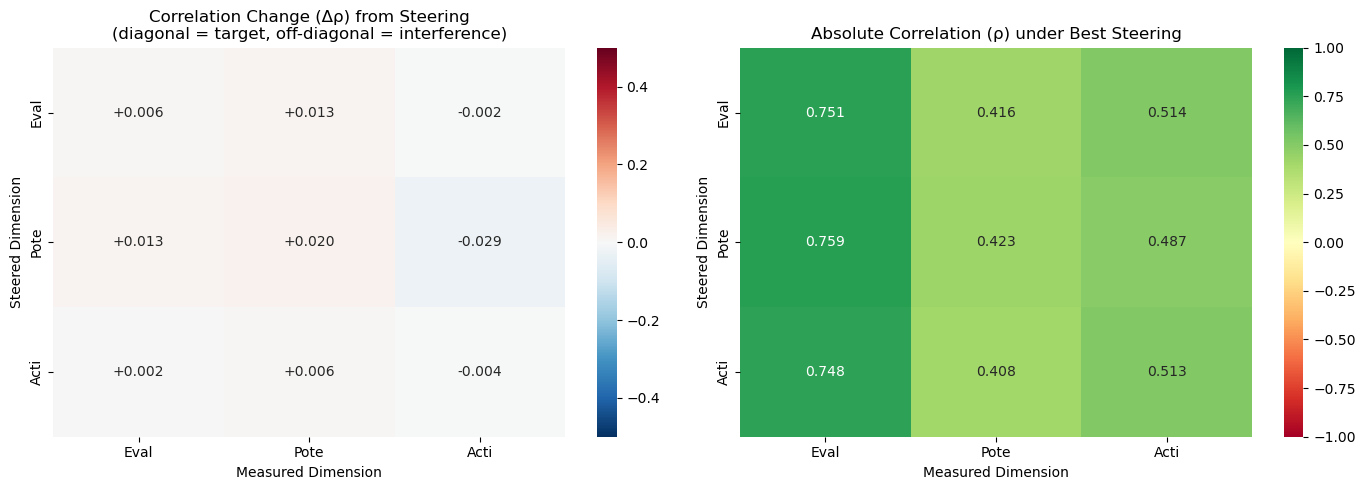


Interference matrix saved to interference_matrix.png


In [8]:
# === Cell 9: Cross-Dimension Interference Matrix ===
#
# Shows how steering each dimension affects correlations on all dimensions.
# Rows = steered dimension, Columns = measured dimension.
# Diagonal = on-target improvement, off-diagonal = interference.

interference_matrix = np.zeros((3, 3))
absolute_matrix = np.zeros((3, 3))

for i, steer_dim in enumerate(DIMENSIONS):
    entry = best_params[steer_dim]
    for j, meas_dim in enumerate(DIMENSIONS):
        interference_matrix[i, j] = entry['correlation_deltas'][meas_dim]
        absolute_matrix[i, j] = entry['correlations'][meas_dim]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Delta matrix (interference)
dim_labels = [d.capitalize()[:4] for d in DIMENSIONS]

sns.heatmap(interference_matrix, annot=True, fmt="+.3f", cmap="RdBu_r",
            center=0, vmin=-0.5, vmax=0.5,
            xticklabels=dim_labels, yticklabels=dim_labels,
            ax=axes[0])
axes[0].set_xlabel("Measured Dimension")
axes[0].set_ylabel("Steered Dimension")
axes[0].set_title("Correlation Change (Δρ) from Steering\n(diagonal = target, off-diagonal = interference)")

# Absolute correlation matrix
sns.heatmap(absolute_matrix, annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=-1, vmax=1,
            xticklabels=dim_labels, yticklabels=dim_labels,
            ax=axes[1])
axes[1].set_xlabel("Measured Dimension")
axes[1].set_ylabel("Steered Dimension")
axes[1].set_title("Absolute Correlation (ρ) under Best Steering")

plt.tight_layout()
plt.savefig("interference_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nInterference matrix saved to interference_matrix.png")

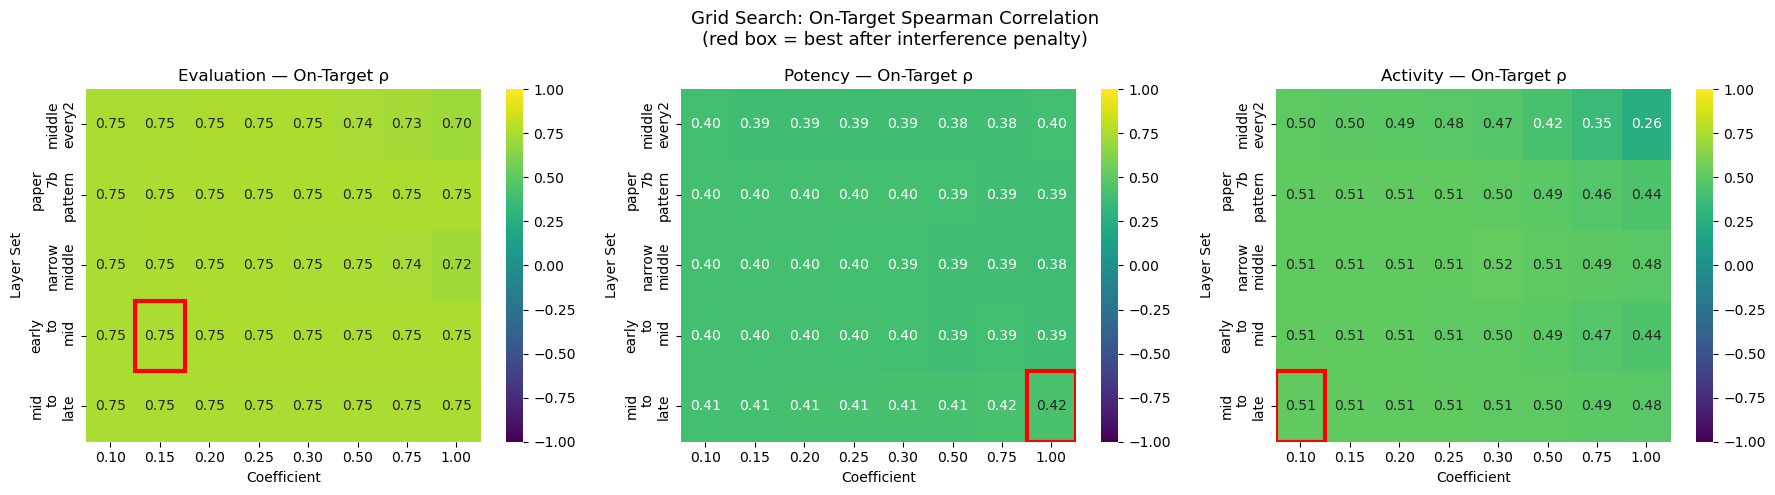

Heatmaps saved to grid_search_heatmaps.png


In [9]:
# === Cell 10: Grid Search Heatmaps ===
#
# Visualize the on-target correlation for each (layer_set, coefficient)
# combination as a heatmap, one per EPA dimension.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

layer_names = list(LAYER_CANDIDATES.keys())

for idx, steer_dim in enumerate(DIMENSIONS):
    # Build matrix: rows = layer sets, cols = coefficients
    matrix = np.zeros((len(layer_names), len(COEFF_CANDIDATES)))
    
    for entry in grid_results[steer_dim]:
        row = layer_names.index(entry['layer_name'])
        col = COEFF_CANDIDATES.index(entry['coefficient'])
        matrix[row, col] = entry['correlations'][steer_dim]
    
    sns.heatmap(
        matrix, annot=True, fmt=".2f", cmap="viridis",
        xticklabels=[f"{c:.2f}" for c in COEFF_CANDIDATES],
        yticklabels=[n.replace('_', '\n') for n in layer_names],
        ax=axes[idx],
        vmin=-1, vmax=1,
    )
    axes[idx].set_xlabel("Coefficient")
    axes[idx].set_ylabel("Layer Set")
    axes[idx].set_title(f"{steer_dim.capitalize()} — On-Target ρ")
    
    # Mark the best cell
    best = best_params[steer_dim]
    best_row = layer_names.index(best['layer_name'])
    best_col = COEFF_CANDIDATES.index(best['coefficient'])
    axes[idx].add_patch(plt.Rectangle(
        (best_col, best_row), 1, 1,
        fill=False, edgecolor='red', linewidth=3
    ))

plt.suptitle("Grid Search: On-Target Spearman Correlation\n(red box = best after interference penalty)",
             fontsize=13)
plt.tight_layout()
plt.savefig("grid_search_heatmaps.png", dpi=150, bbox_inches='tight')
plt.show()

print("Heatmaps saved to grid_search_heatmaps.png")

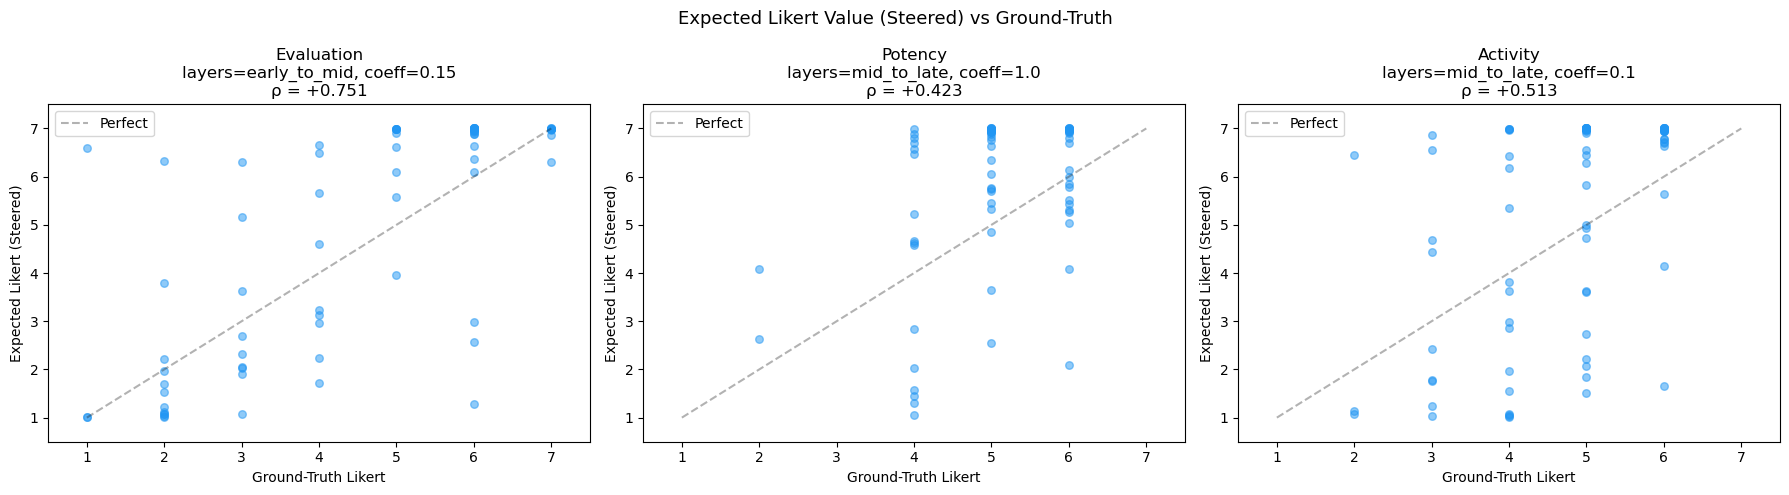

Scatter plots saved to scatter_best_params.png


In [10]:
# === Cell 11: Scatter Plots — Best Hyperparameters ===
#
# For the best hyperparameters, re-run steering and plot
# expected Likert value vs ground-truth for each dimension.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, steer_dim in enumerate(DIMENSIONS):
    best = best_params[steer_dim]
    neg_layers = best['layers_neg']
    pos_layers = best['layers_pos']
    coeff = best['coefficient']
    
    # Apply steering — activations use NEGATIVE keys, wrap uses POSITIVE
    kwargs = {f"{d[0]}_coeff": 0.0 for d in DIMENSIONS}
    kwargs[f"{steer_dim[0]}_coeff"] = coeff
    
    activations_neg = make_epa_activations(
        rep_readers=rep_readers,
        layers=neg_layers,
        device=model.device,
        dtype=model.dtype,
        normalize=True,
        **kwargs,
    )
    activations_pos = {
        n_layers + k: v for k, v in activations_neg.items()
    }
    
    wrapped_model.unwrap()
    wrapped_model.wrap_block(pos_layers, block_name="decoder_block")
    wrapped_model.set_controller(pos_layers, activations_pos, "decoder_block")
    
    steered_vals = []
    gt_vals = []
    for u in tqdm(utterances, desc=f"Scatter {steer_dim[:4]}", leave=False):
        prompt = make_likert_prompt(u['text'], steer_dim)
        result = compute_likert_distribution(model, tokenizer, prompt, steer_dim)
        steered_vals.append(result['expected_value'])
        gt_vals.append(LIKERT_VALUES[u['likert_targets'][steer_dim]])
    
    wrapped_model.reset()
    wrapped_model.unwrap()
    
    # Plot
    rho, _ = spearmanr(steered_vals, gt_vals)
    axes[idx].scatter(gt_vals, steered_vals, alpha=0.5, s=30, c='#2196F3')
    axes[idx].plot([1, 7], [1, 7], 'k--', alpha=0.3, label='Perfect')
    axes[idx].set_xlabel("Ground-Truth Likert")
    axes[idx].set_ylabel("Expected Likert (Steered)")
    axes[idx].set_title(
        f"{steer_dim.capitalize()}\n"
        f"layers={best['layer_name']}, coeff={coeff}\n"
        f"ρ = {rho:+.3f}"
    )
    axes[idx].set_xlim(0.5, 7.5)
    axes[idx].set_ylim(0.5, 7.5)
    axes[idx].set_xticks(range(1, 8))
    axes[idx].legend()

plt.suptitle("Expected Likert Value (Steered) vs Ground-Truth", fontsize=13)
plt.tight_layout()
plt.savefig("scatter_best_params.png", dpi=150, bbox_inches='tight')
plt.show()

print("Scatter plots saved to scatter_best_params.png")

In [11]:
# === Cell 12: Save Results ===

results_output = {
    "metadata": {
        "model_name": model_name,
        "tuned_at": datetime.now().isoformat(),
        "dataset_path": DATASET_PATH,
        "n_utterances": len(utterances),
        "interference_penalty": INTERFERENCE_PENALTY,
    },
    "layer_candidates": {k: v for k, v in LAYER_CANDIDATES.items()},
    "coeff_candidates": COEFF_CANDIDATES,
    "best_hyperparameters": {},
    "baseline_correlations": {},
}

for dim in DIMENSIONS:
    rho_base, _ = spearmanr(baseline_expected[dim], ground_truth[dim])
    results_output["baseline_correlations"][dim] = float(rho_base)
    
    best = best_params[dim]
    results_output["best_hyperparameters"][dim] = {
        "layer_name": best['layer_name'],
        "layers_neg": best['layers_neg'],
        "layers_pos": best['layers_pos'],
        "coefficient": best['coefficient'],
        "on_target_correlation": best['correlations'][dim],
        "on_target_delta": best['correlation_deltas'][dim],
        "cross_dim_correlations": {
            d: best['correlations'][d] for d in DIMENSIONS if d != dim
        },
        "cross_dim_deltas": {
            d: best['correlation_deltas'][d] for d in DIMENSIONS if d != dim
        },
    }

# Also save full grid results for later analysis
results_output["full_grid_results"] = grid_results

results_path = "epa_tuning_results.json"
with open(results_path, 'w') as f:
    json.dump(results_output, f, indent=2)

print(f"Results saved to {results_path}")
print("\n" + "="*60)
print("SUMMARY — Best Hyperparameters")
print("="*60)
for dim in DIMENSIONS:
    b = results_output['best_hyperparameters'][dim]
    print(f"\n{dim.upper()}:")
    print(f"  Layers:      {b['layer_name']} = neg{b['layers_neg']} / pos{b['layers_pos']}")
    print(f"  Coefficient: {b['coefficient']}")
    print(f"  ρ (target):  {b['on_target_correlation']:+.3f} (Δ={b['on_target_delta']:+.3f})")

Results saved to epa_tuning_results.json

SUMMARY — Best Hyperparameters

EVALUATION:
  Layers:      early_to_mid = neg[-9, -12, -15, -18, -21, -24] / pos[23, 20, 17, 14, 11, 8]
  Coefficient: 0.15
  ρ (target):  +0.751 (Δ=+0.006)

POTENCY:
  Layers:      mid_to_late = neg[-3, -6, -9, -12, -15, -18] / pos[29, 26, 23, 20, 17, 14]
  Coefficient: 1.0
  ρ (target):  +0.423 (Δ=+0.020)

ACTIVITY:
  Layers:      mid_to_late = neg[-3, -6, -9, -12, -15, -18] / pos[29, 26, 23, 20, 17, 14]
  Coefficient: 0.1
  ρ (target):  +0.513 (Δ=-0.004)
